# Retrieving water quality data from the Environment Agency's new API

date: 2026-03-08
tags: water-quality, EA, API, python, polars
description: A demonstration of retrieving water quality data from the EA's new API
image: output_20_0.png
draft: false
<!--eofm-->

The Environment Agency has a treasure trove of data on water quality in English rivers, made openly available via a [web portal](https://environment.data.gov.uk/water-quality), with an accompanying [API](https://environment.data.gov.uk/water-quality/api-docs).

Back at the end of last year (2025) the EA [refreshed the web portal](https://environment.data.gov.uk/support/announcements/275811286/785973249), removing a handy option to bulk download data. At the same time, they committed the cardinal sin of [completely changing their API](https://environment.data.gov.uk/support/announcements/275811447/1156939777), deprecating their old API at the same time, with very little notice. Those of us that used the old API were left with broken scripts and fair barrier to accessing the data, compounding by [rather opaque documentation](https://environment.data.gov.uk/water-quality/api-docs).

I have been digging into the new API over the past few days, and thought it would be useful to show a few quick, tangible examples of how it can be used.

## Prerequisites

I am using Python's [Requests](https://docs.python-requests.org/en/latest/index.html) library, coupled with [Polars](https://pola.rs/) to process the data (because Pandas is _so_ last year) and Ploty to plot. To follow along, you will need to install reasonably recent (as of March 2026) versions of these. Plotly Express also needs NumPy to work, and (because I am rendering the graph as a PNG to display on this website), Kaleido is needed to. I recommend using the [Pixi package manager](https://pixi.prefix.dev/latest/installation/) (because Conda is _so_ last year). To create a new Pixi workspace in your current folder with an associated environment containing the required packages, run:

```bash
pixi init
pixi add python polars plotly numpy python-kaleido
```

{{< notice tip "Jupyter Notebooks" >}}
If you want to write your code in a Jupyter Notebook, then run `pixi add jupyterlab` too. You can then start JupyterLab by running `pixi run jupyter lab`.
{{< /notice >}}

## All observations in a given date range

The nomenclature of the API is confusing, but if you are interested in *measured values for different water quality parameters* (determinands), then *observations* are what you are after. To give a fuller explanation: Observations are measurements taken on a *sample*, which are taking during *sampling* at a *sampling point*, and include the determinand and a value (given in a column called "result"). I said it was confusing...

Fortunately, there is a convenient API POST endpoint for retrieving observations: `/data/observations`. A series of filters can be passed as parameters to this endpoint, including `determinand` (if you are interested in only one properties - more on that later), `date` (filter by exact date), `dateFrom` and `dateTo`, and a host of coordinate parameters (`easting`, `northing`, `latitude`, `longitude`, `radius`) for "radius-based searches", and many more. These are all theoretically optional, but you might stumble across errors if you try to retrieve too much data at once. For example, you have to specify dates unless you are requesting data for a specific sampling point.

{{< notice tip "Pagination" >}}
An addition to the new API is that all results are paginated, presumably to stop people asking for too much data in one request. This is controlled by a `limit` and `skip` parameter. `limit` tells the API how many data points (observations) to retrieve. Confusingly, the maximum you can request is different depending on whether you want the data returned as JSONLD (250), JSONLINES (2500) or CSV (2500). `skip` indicates how many data points to, well, skip. So, a typical paginated request might look something like this:

```python
offset = 0
limit = 2500
while True:
    r = requests.post(..., params={'skip': offset, 'limit': limit})
    if r.text == '':
        break
    offset += limit
```
{{< /notice >}}

Let's start by getting all measurements taken in, say, the first week of January 2026. We can use this endpoint to build a query and retrieve the data. I want the data as a CSV, so I am using Polars dataframes to store them. Because the data are paginated, I first have to create a list of dataframes, and then concat them into one.

In [20]:
import io
import requests
import polars as pl
import plotly.express as px

# Empty list to store dataframes in
dfs = []
# Pagination params
offset = 0
limit = 2500   # This is the max allowed for CSV

# Loop until we have all data
while True:
    # Run the API request
    print(f'Retrieving records {offset} to {offset + limit}...')
    r = requests.post(
        'https://environment.data.gov.uk/water-quality/data/observation',
        params={
            'skip': offset,
            'limit': limit,
            'dateFrom': '2026-01-01',
            'dateTo': '2026-01-07',
        },
        headers={
            'Accept': 'text/csv',
            'CSV-Header': 'present',
            'API-Version': '1',
            'Content-Type': 'application/json'
        }
    )
    # Check if the request was successful. If not, you might need
    # to do more digging into the response (e.g. looking at r.text)
    # to get the full explanation
    r.raise_for_status()
    # Check if we've got all the data yet. Could be handled more elegantly!
    if r.text == '':
        break
    # Create a dataframe from the CSV response. We need to override
    # the dtype of the 'result' column to a string (Utf8) because it
    # can contain non-numeric values. Polars infers dtypes by
    # reading a certain number of rows, and so it often incorrectly
    # thinks that 'result' is a float. If you are using Pandas, this
    # shouldn't be an issue as it is more permissive
    df = pl.read_csv(io.BytesIO(r.content),
                     schema_overrides={'result': pl.Utf8})
    # Add to our list of dataframes
    dfs.append(df)
    # Increment the offset for the next request
    offset += limit

# Concat the dataframes into one big dataframe
df = pl.concat(dfs)

Retrieving records 0 to 2500...
Retrieving records 2500 to 5000...
Retrieving records 5000 to 7500...
Retrieving records 7500 to 10000...
Retrieving records 10000 to 12500...
Retrieving records 12500 to 15000...
Retrieving records 15000 to 17500...
Retrieving records 17500 to 20000...
Retrieving records 20000 to 22500...
Retrieving records 22500 to 25000...
Retrieving records 25000 to 27500...


Now we have our data, we can see what columns it contains (information which is inconveniently absent from the official docs):

In [21]:
df.columns

['id',
 'samplingPoint.notation',
 'samplingPoint.prefLabel',
 'samplingPoint.easting',
 'samplingPoint.northing',
 'samplingPoint.region',
 'samplingPoint.area',
 'samplingPoint.subArea',
 'samplingPoint.samplingPointStatus',
 'samplingPoint.samplingPointType',
 'phenomenonTime',
 'samplingPurpose',
 'sampleMaterialType',
 'determinand.notation',
 'determinand.prefLabel',
 'result',
 'unit']

There is lots of information, but perhaps the most useful columns are the `determinand.notation` and `determinand.prefLabel` columns, telling us what the measurement is of (see below for more on determinands), and the `result` and `unit` columns, telling us the value and unit of measurement.

Note that, as commented in the above code, we read the `result` as a string, because it might contain non-numeric values like "<10". Further parsing of these data is required to make them useful. Firstly, I want to know what non-numeric values are in the column. I will use Polars to try and cast the values as a float, and filter out values where this casting is successful. I also know that lots of values start with "<" or ">", and I'm not interested in knowing these, so I filter them out too. Then I drop the duplicates by using `unique()`.

In [22]:
df.filter(pl.col('result').cast(pl.Float64, strict=False).is_null()
          & pl.col('result').is_not_null()
          & ~pl.col('result').str.starts_with('<')
          & ~pl.col('result').str.starts_with('>')
).unique('result')['determinand.prefLabel', 'result', 'unit']

determinand.prefLabel,result,unit
str,str,str
"""Flow Type""","""Ponded / Still""","""Coded Result"""
"""Phytoplankton""","""Sample sent to subcontract lab""","""Coded Result"""
"""Flow Type""","""Low Flow""","""Coded Result"""
"""Weather : Cloud Cover""","""8/8 cloud cover""","""Coded Result"""
"""Flow Type""","""Frozen""","""Coded Result"""
…,…,…
"""Descriptive Site Inspection : …","""Pass""","""Coded Result"""
"""MST Filtration""","""DNA Stored""","""Coded Result"""
"""No flow /No sample""","""No flow/discharge at sampling …","""Coded Result"""


As you can see, a lot of the results are for qualitative determinands like "Flow Type". How you deal with these rows depends on what you are trying to achieve with your analysis. For example, maybe you only want quantitative results, in which case you would simply filter out all non-numeric values:

In [27]:
df = (df.filter(pl.col('result').cast(pl.Float64, strict=False).is_not_null())
        .with_columns(pl.col('result').cast(pl.Float64)))

# Now you can do something like find the median value of each determinand.
# Theoretically, each determinand should have a unique unit, but that's
# not strictly true, so be careful doing this type of operation
df.group_by('determinand.prefLabel').agg(
    pl.col('result').median(),
    pl.col('unit').first()
)


determinand.prefLabel,result,unit
str,f64,str
"""Phosphorus, Total as P""",0.11,"""MILLIGRAM PER LITRE"""
"""Magnesium""",6.5,"""MILLIGRAM PER LITRE"""
"""Hardness, Total as CaCO3""",262.5,"""MILLIGRAM PER LITRE"""
"""Arsenic, Dissolved""",1.75,"""MICROGRAM PER LITRE"""
"""Chromium, Dissolved""",0.92,"""MICROGRAM PER LITRE"""
…,…,…
"""Zinc, Dissolved""",4.55,"""MICROGRAM PER LITRE"""
"""Ammoniacal Nitrogen : Load""",0.535,"""TONNE/DAY"""
"""3-Methylphenol :- {m-Cresol}""",0.319,"""MICROGRAM PER LITRE"""


## Observations for a particular determinand near a particular location

Perhaps a more likely scenario is that you have a particular determinand (water quality parameter) that you are interested in. Let's take pH as an example. To retrieve entries for a particular determinand, we need to know its "notation" (sometimes called its "code", depending on which bit of the docs you read). If you don't already know this, then you need to use another API endpoint to try and figure it out: `/codelist/determinand`. We have to search by the so-called "prefLabel", which as you can see from the tables above, is a text-based description of the determinand. Let's give pH a go: 

In [29]:
# Function to search for a determinand by its prefLabel
def search_for_determinand(pref_label):
    r = requests.get(
        'https://environment.data.gov.uk/water-quality/codelist/determinand',
        params={
            'limit': 250,
            'prefLabel': pref_label
        },
        headers={
            'accept': 'application/ld+json',
            'API-Version': '1',
        }
    )
    r.raise_for_status()
    return r.json()

# Search for "pH" and see how many results are returned
r = search_for_determinand('pH')
len(r['member'])

250

Turns out the search is pretty useless if your search phrase ("pH") is contained in lots of other words... We've actually hit the 250 limit, and so if we want to load all of the results, we would have to use pagination. Before doing this, let's first check if "pH" is already contained in this list, by working on the presumption that `prefLabel = 'pH'`. Honestly, it would have been a lot easier if they just provided us a big table...

In [30]:
for determinand in r['member']:
    if determinand['prefLabel'] == 'pH':
        print(determinand['notation'])

0061


{{< notice warning "Same property; multiple determinands" >}}
Some properties, with the same "prefLabel", have multiple determinands. This is usually because they have different units - not that the information you get back from the `codelist/determinand` endpoint gives any indication as to this, nor is there any other endpoint that I can find that gives this information *except for* as part of the data returned when you search for observations. Confusing.
{{< /notice >}}

Now we have the notation to search by: 0061. Let's try and search for all measurements of pH within a 10 km radius of Lancaster University, making use of the radius-based search function. Unless you specify an individual sampling point, the API requires that you limit the request to a year or less, so let's look for data from 2025.

In [31]:
# Empty list to store dataframes in
dfs = []
# Pagination params
offset = 0
limit = 2500   # This is the max allowed for CSV

# Loop until we have all data
while True:
    # Run the API request
    print(f'Retrieving records {offset} to {offset + limit}...')
    r = requests.post(
        'https://environment.data.gov.uk/water-quality/data/observation',
        params={
            'skip': offset,
            'limit': limit,
            'dateFrom': '2025-01-01',
            'dateTo': '2025-12-31',
            'determinand': '0061',  # pH
            'latitude': 54.01,      # Lancaster Uni
            'longitude': -2.79,
            'radius': 10            # 10km radius around Lancaster Uni
        },
        headers={
            'Accept': 'text/csv',
            'CSV-Header': 'present',
            'API-Version': '1',
            'Content-Type': 'application/json'
        }
    )
    # Check if the request was successful
    r.raise_for_status()
    # Check if we've got all the data yet
    if r.text == '':
        break
    # Create a dataframe from the CSV response
    df = pl.read_csv(io.BytesIO(r.content),
                     schema_overrides={'result': pl.Utf8})
    dfs.append(df)
    # Increment the offset for the next request
    offset += limit

# Concat the dataframes and save
df = pl.concat(dfs)

Retrieving records 0 to 2500...
Retrieving records 2500 to 5000...


Let's see how many sampling points were found in the search, and how many observations each have:

In [33]:
df['samplingPoint.prefLabel'].value_counts(sort=True)

samplingPoint.prefLabel,count
str,u32
"""RIVER LUNE AT DENNY BRIDGENEW …",12
"""RSN0348 WYRE D/S SPARROW GILL""",12
"""RSN1320 GRIZEDALE BROOK @ PEDD…",12
"""RIVER CONDER AT CONDER GREEN""",7
"""RIVER LUNE AT FORGE BANK WEIRK…",6
…,…
"""CATSHAW HALL FARM BH …",2
"""LOW MOOR HEAD FARM …",2
"""LOWER BURROW FARM WELL SD45/9""",2


Let's take example of the Wyre at Sparrow Gill. We can pull out the pH data and plot as a timeseries:

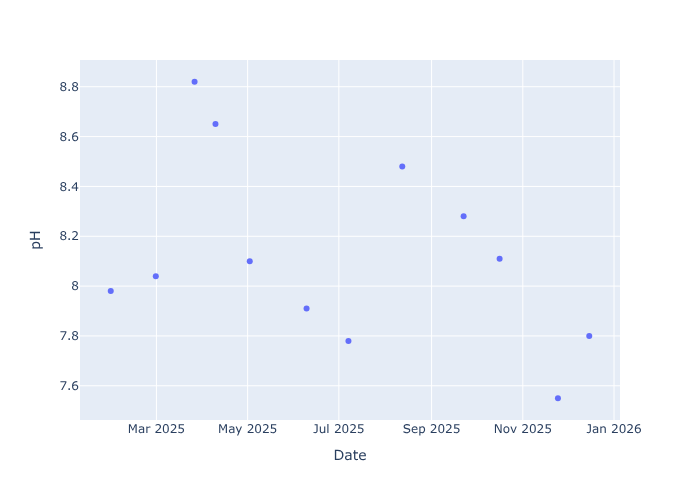

In [34]:
# Filter the dataframe to just Sparrow Gill
df_sg = df.filter(pl.col('samplingPoint.prefLabel') == 'RSN0348 WYRE D/S SPARROW GILL')
# Cast result as float (they should all be numeric) and phenomenonTime
# as datetime
df_sg = df_sg.with_columns(pl.col('result').cast(pl.Float64),
                           pl.col('phenomenonTime').cast(pl.Datetime))
# Plot the time series
fig = px.scatter(df_sg, x='phenomenonTime', y='result',
                 labels={'phenomenonTime': 'Date', 'result': 'pH'})
fig.show(renderer='png')


The API is obviously more comprehensive than the brief examples I've given here, though for the common task of retrieving observations across sites and date ranges, these are probably the most relevant workflows. The full API documentation is [here](https://environment.data.gov.uk/water-quality/api-docs), though a degree of trial and error is required to correctly interpret the more ambiguous parts of it. Good luck!